import pandas as pd

In [3]:
import seaborn as sns

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings


In [7]:
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

Getting the Data

In [12]:
df = pd.read_csv("diabetes 2.csv")

In [14]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [20]:
print('Dataset Shape:', df.shape)
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (768, 9)
Rows: 768, Columns: 9

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [59]:
print(f"DEBUG: My columns are actually: {list(df.columns)}")
FEATURES = ["BMI", "Age", "Glucose", "BloodPressure"]
X = df[FEATURES] 
y = df["Outcome"]

# Re-split and Re-train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # This now "memorizes" only 4 features

model = LogisticRegression()
model.fit(X_train_s, y_train)
print("Model retrained on 4 features!")

DEBUG: My columns are actually: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Model retrained on 4 features!


Training and Saving Model

In [61]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_s, y_train)

joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")
print("Model saved.")

y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print("── Model Performance ──────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic", "Diabetic"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Model saved.
── Model Performance ──────────────────────────────
              precision    recall  f1-score   support

Non-Diabetic       0.65      0.72      0.68        99
    Diabetic       0.38      0.31      0.34        55

    accuracy                           0.57       154
   macro avg       0.51      0.51      0.51       154
weighted avg       0.55      0.57      0.56       154

ROC-AUC: 0.531


Risk Reduction Function

Example of Prediction

In [63]:
def predict_risk(bmi, age, glucose, blood_pressure):
    # Get the EXACT names the scaler expects
    expected_features = scaler.feature_names_in_
    
    # Create the DataFrame using those exact names
    input_data = pd.DataFrame(
        [[bmi, age, glucose, blood_pressure]], 
        columns=expected_features
    )
    
    # Now transform and predict
    patient_scaled = scaler.transform(input_data)
    prob = model.predict_proba(patient_scaled)[0, 1]
    

    # Category Logic
    if prob < 0.30:
        label, advice = "LOW", "Routine screening in 3 years."
    elif prob < 0.60:
        label, advice = "MODERATE", "Lifestyle changes. Re-screen in 12 months."
    else:
        label, advice = "HIGH", "Refer to endocrinologist. Confirm with HbA1c."

    return {"risk_score": round(prob * 100, 1), "label": label, "advice": advice}




In [65]:
# Create a list of test cases
test_patients = [
    ("Healthy/Young", 22.0, 25, 80, 70),
    ("Borderline", 29.5, 40, 125, 80),
    ("High Risk", 35.0, 60, 180, 95)
]

print(f"{'Patient':<20} | {'Score':<10} | {'Risk Level'}")
print("-" * 45)

for name, bmi, age, gluc, bp in test_patients:
    res = predict_risk(bmi, age, gluc, bp)
    print(f"{name:<20} | {res['risk_score']}%{' ':<5} | {res['label']}")

Patient              | Score      | Risk Level
---------------------------------------------
Healthy/Young        | 2.4%      | LOW
Borderline           | 30.5%      | MODERATE
High Risk            | 91.5%      | HIGH


VISUALISATION

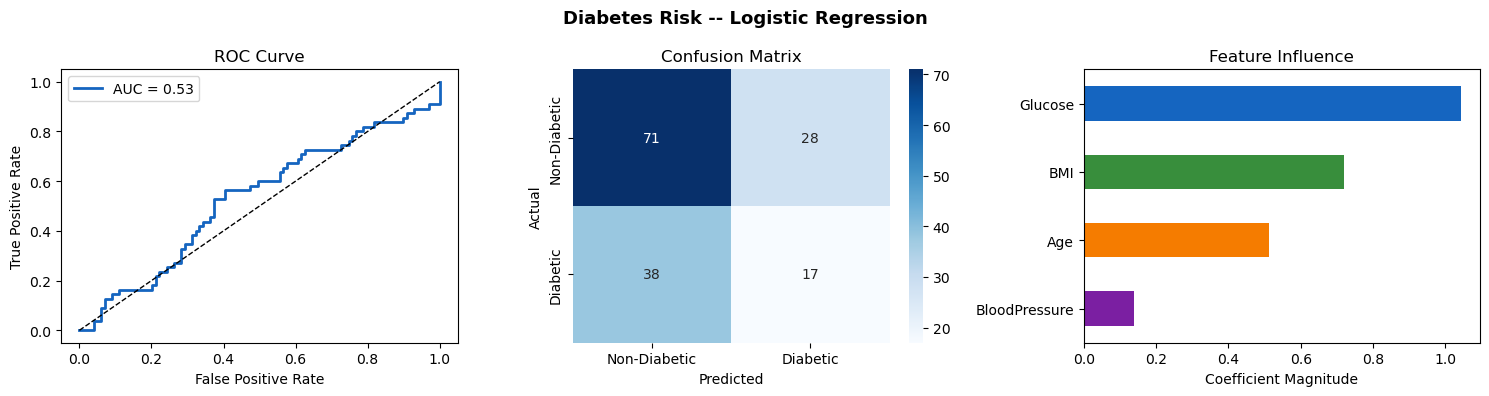

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Diabetes Risk -- Logistic Regression", fontsize=13, fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color="#1565C0", linewidth=2,
             label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Non-Diabetic", "Diabetic"],
            yticklabels=["Non-Diabetic", "Diabetic"])
axes[1].set(title="Confusion Matrix", xlabel="Predicted", ylabel="Actual")

coefs = pd.Series(np.abs(model.coef_[0]), index=FEATURES).sort_values()
coefs.plot.barh(ax=axes[2], color=["#7B1FA2", "#F57C00", "#388E3C", "#1565C0"])
axes[2].set(title="Feature Influence", xlabel="Coefficient Magnitude")

plt.tight_layout()
plt.show()

In [3]:
!pip install streamlit

In [5]:
%%writefile app.py

import streamlit as st
import joblib
import pandas as pd
import numpy as np

# Load saved model and scaler
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("diabetes_scaler.pkl")

# Page config
st.set_page_config(page_title="Diabetes Risk Predictor", page_icon="🏥")

# Title
st.title("🏥 Diabetes Risk Predictor")
st.markdown("**Morning Star Hospital, Port Harcourt, Rivers State, Nigeria**")
st.markdown("*A Comparative Wrapper Based Approach for Predicting Diabetes — ADUN 2026*")
st.divider()

# Input fields
st.subheader("Enter Patient Details")
col1, col2 = st.columns(2)

with col1:
    glucose = st.number_input("Glucose Level (mg/dL)", min_value=50.0, max_value=200.0, value=100.0)
    bmi = st.number_input("BMI (kg/m²)", min_value=10.0, max_value=70.0, value=25.0)

with col2:
    age = st.number_input("Age (years)", min_value=18, max_value=90, value=30)
    bp = st.number_input("Blood Pressure (mmHg)", min_value=40.0, max_value=130.0, value=70.0)

# Predict button
if st.button("Predict Diabetes Risk"):
    input_data = pd.DataFrame(
        [[bmi, age, glucose, bp]],
        columns=scaler.feature_names_in_
    )
    input_scaled = scaler.transform(input_data)
    prob = model.predict_proba(input_scaled)[0][1] * 100

    if prob < 30:
        st.success(f"✅ LOW RISK — {prob:.1f}%")
        st.info("Routine screening in 3 years. Maintain healthy diet and exercise.")
    elif prob < 60:
        st.warning(f"⚠️ MODERATE RISK — {prob:.1f}%")
        st.info("Lifestyle changes recommended. Re-screen in 12 months.")
    else:
        st.error(f"🚨 HIGH RISK — {prob:.1f}%")
        st.info("Refer to endocrinologist. Confirm with HbA1c test immediately.")

st.divider()
st.caption("⚠️ This is a research prototype and not a substitute for professional medical diagnosis.")

Writing app.py


In [9]:
!streamlit run app.py --server.headless true




  You can now view your Streamlit app in your browser.

  Network URL: http://172.20.10.4:8501
  External URL: http://102.90.81.174:8501

^C
  Stopping...


In [ ]:
%%writefile app.py

import streamlit as st 

# This stores whether someone is logged in on not 
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False 
    
# Login page 
st.title("Morning Star Hospital")
st.subheader("Diabetes Risk Prediction System")
st.markdown("---")

username = st.text_input("Username")
password = st.text_input("Password", type="password")

if st.button("Login"):
    if username == "doctor" and password == "adun2026":
        st.session_state.logged_in = True !
        st.success("Login successful!")
    else:
        st.error ("Wrong username or password!")
        

In [ ]:
!streamlit run app.py --server.headless true 

In [ ]:
%%writefile app.py 

import streamlit as st 
# Memory for the app 
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False

# ---- LOGIN PAGE ----
if st.session_state.logged_in == False:
    st.title("Morning Star Hospital")
    st.subheader("Diabetes Risk Predicton System")
    st.markdown("---")

    username = st.text_input("Username")
    password = st.text_input("Password", type="password")

    if st.button("Login"):
        if username == "doctor" and password =="adun2026":
            st.session_state.logged_in = True
            st.rerun()
        else:
            st.error("Wrong username or password")

# ---- HOME PAGE ----
else:
    st.title("Welcome to Morning Star Hospital")
    st.subheader("Diabetes Riisk Prediction System")
    st.markdown("---")
    st.success("You are logged in")
    st.write("Prediction page coming next...")

In [ ]:
with open("app.py", "r") as f:
    print(f.read())